In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, Activation
)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version :", tf.__version__)
print("GPU devices        :", tf.config.list_physical_devices('GPU'))

TensorFlow version : 2.19.0
GPU devices        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully.")

Mounted at /content/drive
Drive mounted successfully.


In [ ]:
BASE_DIR  = "/content/drive/MyDrive/AI ML/Week6/FruitinAmazon/FruitinAmazon"

train_dir = os.path.join(BASE_DIR, "train")
test_dir  = os.path.join(BASE_DIR, "test")

IMAGE_SIZE  = (224, 224)   # height × width
BATCH_SIZE  = 32
NUM_CLASSES = 6

print("train_dir :", train_dir)
print("test_dir  :", test_dir)
assert os.path.isdir(train_dir), "train_dir not found — check your path!"
assert os.path.isdir(test_dir),  "test_dir not found  — check your path!"

train_dir : /content/drive/MyDrive/AI ML/Week6/FruitinAmazon/FruitinAmazon/train
test_dir  : /content/drive/MyDrive/AI ML/Week6/FruitinAmazon/FruitinAmazon/test


In [ ]:
# Each sub-directory inside train_dir represents one class label
class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("ERROR: No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

# Expected output:
# Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
corrupted_images = []   # collect paths of corrupted files

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()   # verify image integrity
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print(f"\n{len(corrupted_images)} corrupted image(s) found:")
    for path in corrupted_images:
        print("  ", path)
        os.remove(path)
    print("All corrupted images removed.")
else:
    print("No corrupted images found.")

# Expected output:
# No corrupted images found.

No corrupted images found.


In [ ]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        class_counts[class_name] = len(images)

# Print distribution table
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for cls, cnt in class_counts.items():
    print(f"{cls:<25}{cnt:>15}")
print("=" * 45)

# Expected output:
# acai                               15
# cupuacu                            15
# graviola                           15
# guarana                            15
# pupunha                            15
# tucuma                             15


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


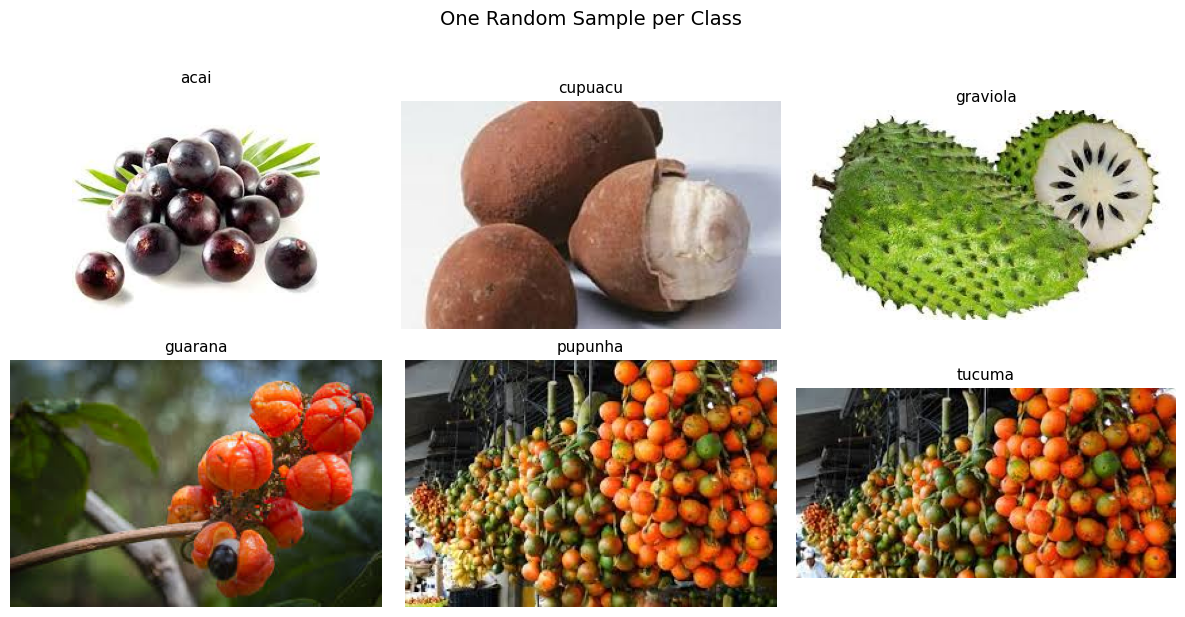

In [ ]:
selected_images = []   # store one image path per class
selected_labels = []   # store corresponding class names

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

# Display in a 2-row grid
num_classes = len(selected_images)
cols = (num_classes + 1) // 2   # 3 columns for 6 classes
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i], fontsize=11)
        ax.axis("off")
    else:
        ax.axis("off")   # hide empty subplots

plt.suptitle("One Random Sample per Class", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

# train_ds and val_ds are tf.data.Dataset objects.
# They do not have a fixed shape — they yield batches when iterated.
print("Class names:", train_ds.class_names)

# Inspect one batch shape
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)   # (32, 224, 224, 3)
    print("Labels shape:", labels.shape)   # (32,)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Images shape: (32, 224, 224, 3)
Labels shape: (32,)


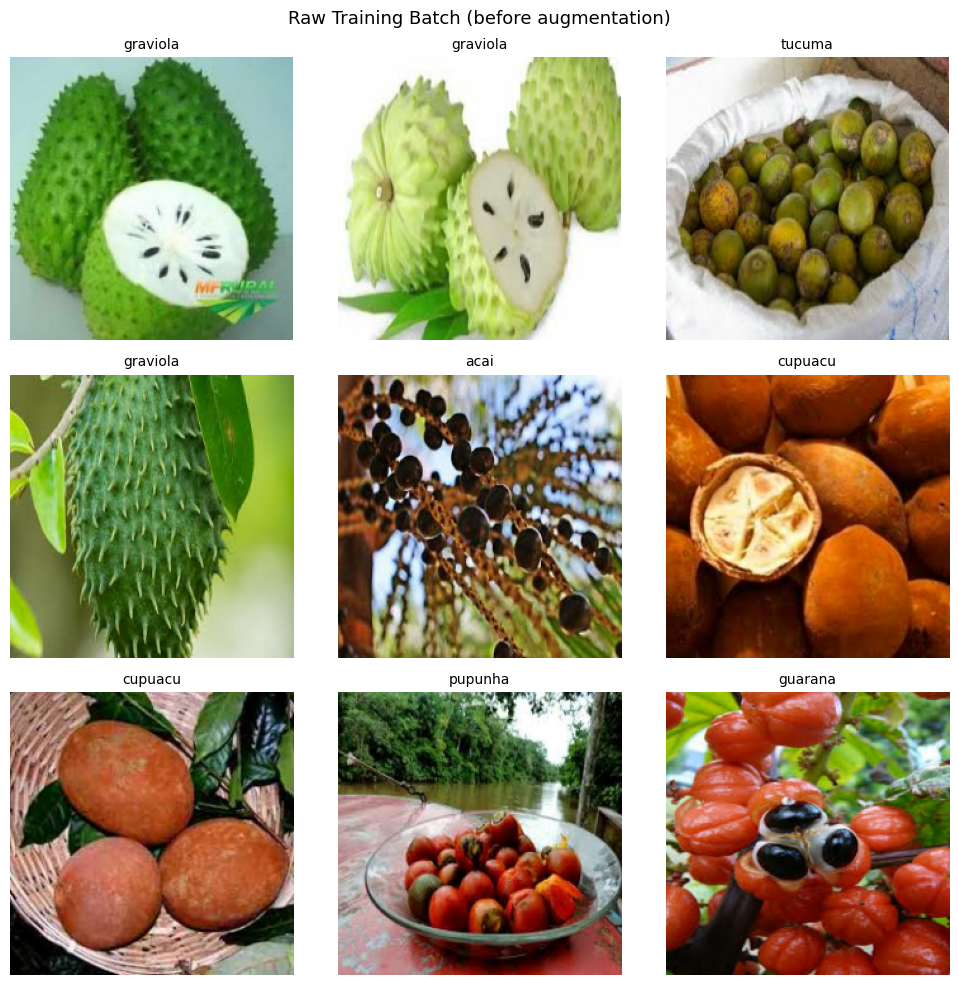

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):   # take one batch from dataset
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(train_ds.class_names[labels[i]], fontsize=10)
        plt.axis("off")
plt.suptitle("Raw Training Batch (before augmentation)", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Define augmentation layers — will be embedded inside the model
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),     # horizontal mirror
    layers.RandomRotation(0.1),          # ±10% of 360°
]

def data_augmentation(images):
    """Apply all augmentation layers sequentially to a batch."""
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

# NOTE: You can add more augmentation layers for your project.
# Check Keras docs: https://keras.io/api/layers/preprocessing_layers/
# e.g. layers.RandomZoom, layers.RandomTranslation, layers.RandomContrast

print("Augmentation layers defined:")
for l in data_augmentation_layers:
    print(f"  {l.__class__.__name__}")

Augmentation layers defined:
  RandomFlip
  RandomRotation


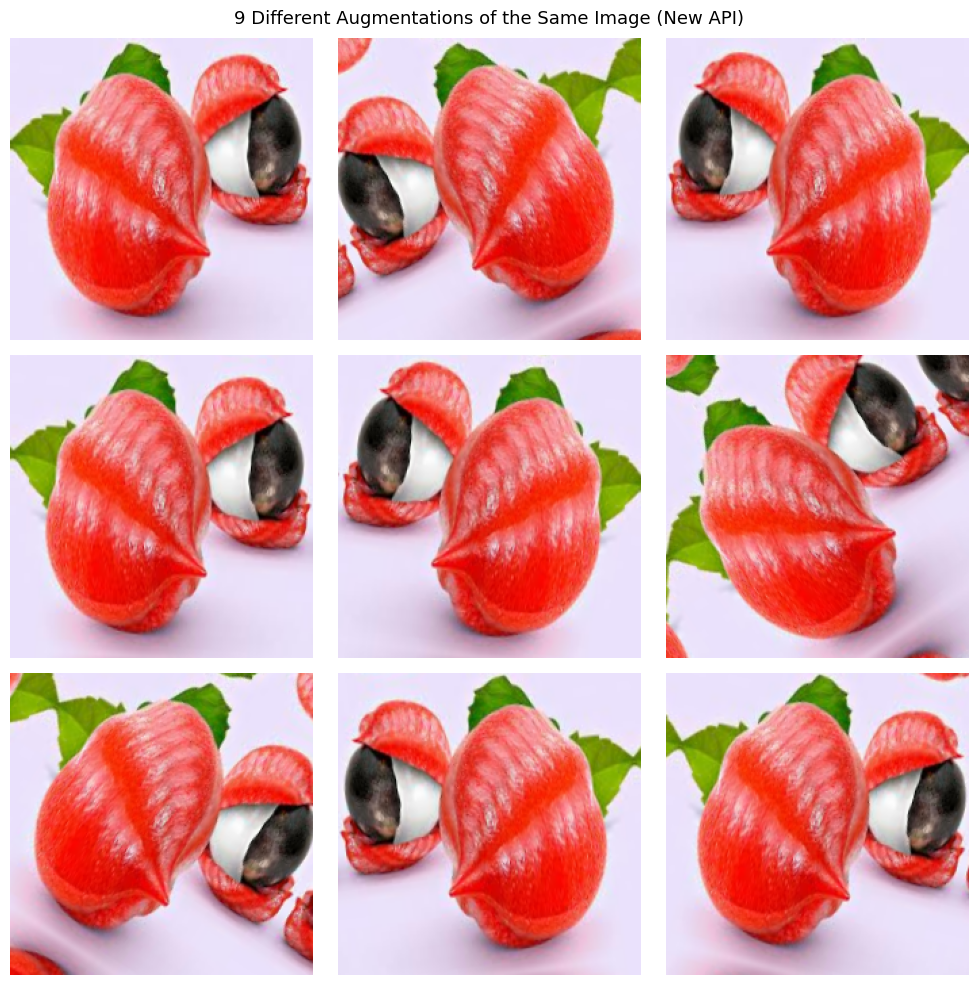

In [ ]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)           # new random transform each call
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))  # show first image each time
        plt.axis("off")
plt.suptitle("9 Different Augmentations of the Same Image (New API)", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

# cache()    → stores dataset in RAM after first epoch (fast for small datasets)
# prefetch() → overlaps I/O and GPU compute
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Pipelines optimised with cache + prefetch. ✓")

Pipelines optimised with cache + prefetch. ✓


In [ ]:
input_shape = IMAGE_SIZE + (3,)   # (224, 224, 3)

model = Sequential([

    layers.Input(shape=input_shape),

    # ── Augmentation + Rescaling ─────────────────────────────────────────────
    layers.Lambda(data_augmentation),   # GPU-accelerated; disabled at eval/predict
    layers.Rescaling(1.0 / 255),        # [0,255] → [0,1]

    # ── Convolutional Block 1 ────────────────────────────────────────────────
    # padding='same' keeps spatial dims after convolution
    # activation=None → BN then Activation added separately
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),               # 224 → 112
    Dropout(0.25),

    # ── Convolutional Block 2 ────────────────────────────────────────────────
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),               # 112 → 56
    Dropout(0.25),

    # ── Convolutional Block 3 ────────────────────────────────────────────────
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),               # 56 → 28
    Dropout(0.25),

    # ── Convolutional Block 4 ────────────────────────────────────────────────
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),               # 28 → 14
    Dropout(0.25),

    # ── Flatten ──────────────────────────────────────────────────────────────
    # Converts (14, 14, 256) feature maps → 1D vector of 50,176 values
    Flatten(),

    # ── Fully Connected Block 1 ──────────────────────────────────────────────
    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # ── Fully Connected Block 2 ──────────────────────────────────────────────
    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # ── Fully Connected Block 3 ──────────────────────────────────────────────
    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # ── Fully Connected Block 4 ──────────────────────────────────────────────
    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # ── Output Layer ─────────────────────────────────────────────────────────
    # 6 neurons = 6 fruit classes
    # softmax converts raw logits into a probability distribution summing to 1
    Dense(NUM_CLASSES, activation='softmax')

], name="FruitsInAmazon_CNN_BN_Dropout")

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',   # integer labels → sparse variant
    metrics=['accuracy']
)

model.summary()

Model: "FruitsInAmazon_CNN_BN_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             

 Total params: 26,257,670 (100.17 MB)

 Trainable params: 26,254,790 (100.15 MB)

 Non-trainable params: 2,880 (11.25 KB)